# 0. Libraries

## 0.1 Libraries Import

In [1]:
import pandas as pd
import numpy as np
import math

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree

from scipy.stats import randint
import statsmodels.api as sm

import markdown

import warnings
warnings.filterwarnings('ignore')


In [2]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso, Ridge

from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier, GradientBoostingClassifier, RandomForestClassifier 
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.utils import class_weight
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from imblearn.pipeline import Pipeline
impipeline = Pipeline

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
import category_encoders as ce

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, RobustScaler

from collections import defaultdict

from sklearn import metrics
from sklearn.metrics import accuracy_score, roc_curve, RocCurveDisplay, roc_auc_score, mean_squared_error
from sklearn.metrics import f1_score, recall_score, precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, fbeta_score
from sklearn.metrics import make_scorer
f2_scorer = make_scorer(fbeta_score, beta=2)
f05_scorer = make_scorer(fbeta_score, beta=0.5)

from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, cross_validate

import shap

from scipy.stats import chi2_contingency, pointbiserialr

import dice_ml
from dice_ml import Data, Model, Dice

## 0.2. Load Data

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
df_bank = pd.read_csv('bank-additional-full.csv', sep=';')

In [5]:
df_bank['y'].unique()

array(['no', 'yes'], dtype=object)

In [6]:
df_bank['y'].isna().sum()

np.int64(0)

# 1. Business Metrics Set-up

## 1.0. Dataframe

In [7]:
df_bank_sbx =  df_bank.copy()

In [8]:
df_bank_sbx.y.isna().sum()

np.int64(0)

## 1.1. Marketing Cost Components

In [9]:
# Call Count                                                             (Number of Calls)
monthly_total_calls = df_bank_sbx.groupby(['month'])['campaign'].sum()
avg_monthly_calls = monthly_total_calls.mean()

# Telemarketing Softwar Subscription (per agent)                         (Cost Call Per Telemarketer (Essential))
monthly_subscription = 25

# Telemarketer Agent                                                     (Estimate Telemarketer Wages (Euro))
monthly_agent_wage = 805

# Work Duration                                                          (Effective Works (Days) | Effective Works Hours/ Day | Maximum Minutes in a Month)
monthly_work_days = 20
daily_work_hour = 8
monthly_work_minutes = monthly_work_days * daily_work_hour * 60

# Call Duration                                                          (Standard Maximum Call per Person in minute)
q3_duration =  np.quantile(df_bank_sbx['duration'], 0.75)/60
q1_duration =  np.quantile(df_bank_sbx['duration'], 0.25)/60
iqr_duration = q3_duration - q1_duration
proposed_call_dur_min = q3_duration + iqr_duration
# proposed_call_dur_min = 7

# Expected Max Monthly Call                                              (Expected Maximum call )
avg_monthly_max_callminute = monthly_work_minutes / proposed_call_dur_min

# Minutes Spent Monthly                                                  Number of Minutes in a Month
monthly_minutes_spent = avg_monthly_calls * proposed_call_dur_min

# Agent needed                                                           Number of Telemarketer Needed
avg_agent_needed = math.ceil( avg_monthly_calls / avg_monthly_max_callminute )

# Avg Monthly Telemarketer Cost                                          Estimate Cost for Telemarketing 
avg_monthly_cost_telemarkting = avg_agent_needed * ( monthly_subscription + monthly_agent_wage )

# Cost in minute                                                         Convert cost in Minute
avg_minute_cost_telemarkting = avg_monthly_max_callminute / avg_monthly_cost_telemarkting 

# Cost per call                                                          Avg cost per minute
cost_per_call = avg_minute_cost_telemarkting * proposed_call_dur_min

# Average calls per person
avg_call_per_person = df_bank_sbx['campaign'].mean()

# Total Cost Component : Average final total cost per call
final_avg_cost_per_customer = cost_per_call * avg_call_per_person

In [10]:
final_avg_cost_per_customer

np.float64(2.969745545257655)

## 1.2. Deposit Cost & Benefit Components

**Deposit Interest Income**


In [11]:
#Deposit Amount
deposit_amount = 500

#NIM (Net Interest margin, %) = (Interest Income - Interest Expense) / Average Interest-Earning Assets

#NIM Explains the ratio of net interest income made from asset compred to the total asset
#Interest Income: This is the revenue a bank generates from its assets that earn interest. Key examples include:
    # Loans: Interest earned from mortgages, personal loans, and other lending activities.
    # Securities: Income from investments in government or corporate bonds and other fixed-income instruments.
    # Other Interest-Bearing Assets: Any other assets that generate interest income.
# Interest Expense: This represents the costs a bank incurs for funding itself. It includes:
    # Interest-Bearing Deposits: Interest paid to customers on their savings and checking accounts.
    # Non-Deposit Liabilities: Interest paid on wholesale funding, such as borrowed funds from other banks or issued bonds.
deposit_nim = 0.0279

# Interest Expense to Interest Income Ratio
interest_expense_to_income_ratio = 0.4158

# Interest Rate
interest_rate = deposit_nim / ( 1 - interest_expense_to_income_ratio )

# Total Income Component : Interest Income
interest_income = deposit_amount * interest_rate
interest_income_y2 = (deposit_amount + interest_income) * interest_rate

# Total Cost Component : Interest Expense
interest_expense = interest_income * interest_expense_to_income_ratio

# Total Cost Component : Interest infcome tax
tax_rate = 0.21
deposit_income_tax = interest_income * tax_rate

# Total Cost Component : All components
all_costs = final_avg_cost_per_customer + interest_expense + deposit_income_tax

In [12]:
net_profit = interest_income - deposit_income_tax - interest_expense - final_avg_cost_per_customer
net_profit

np.float64(5.965704643034025)

## 1.3. Portugal Bank Marketing Campaign Performance

In [13]:
#Income
originaldata_income = round( df_bank[df_bank['y']=='yes']['y'].count() * interest_income )

#Costs
originaldata_costs = round( df_bank['y'].count() * all_costs )

#Net Profit
originaldata_net_profit = originaldata_income - originaldata_costs

#Conversion Rate
originaldata_conv_rate = (df_bank[df_bank['y']=='yes']['y'].count() / (df_bank['y'].count())).round(2)

#ROI
originaldata_roi = round( (originaldata_income - originaldata_costs) / originaldata_costs , 2)

In [14]:
campaign_summary_data = [
                        ['Revenue', originaldata_income],
                        ['Cost', originaldata_costs],
                        ['ROI', originaldata_roi],
                        ['Conversion Rate', originaldata_conv_rate],
                        ]
campaign_summary = pd.DataFrame(campaign_summary_data, columns=['Metric', 'Value'])

campaign_summary

,Metric,Value
0,Revenue,110798.00
1,Cost,737805.00
2,ROI,-0.85
3,Conversion Rate,0.11


## 1.4. Functions to calculate Business Metrics

In [15]:
def business_metrics_func(y_true, y_pred, model_nme):
    # Confusion Matrix Components
    TP = sum((y_true == 1) & (y_pred == 1))
    FP = sum((y_true == 0) & (y_pred == 1))
    FN = sum((y_true == 1) & (y_pred == 0))
    TN = sum((y_true == 0) & (y_pred == 0))

    func_income = TP * interest_income
    func_income_y2 = TP * interest_income_y2
    
    func_cost = ( TP * all_costs ) + ( FN * final_avg_cost_per_customer )
    func_cost_y2 = func_cost + ( func_income_y2 * tax_rate )

    func_roi = (func_income - func_cost) / func_cost
    func_roi_y2 = (func_income_y2 - func_cost_y2) / func_cost

    func_conv_rate = TP / (TP + FP)
    
    func_lost_oppt = ( FN * interest_income ) - ( FN * all_costs )
    func_lost_oppt_y2 = func_lost_oppt + ( FN * interest_income_y2 ) - ( FN * deposit_amount * interest_rate * tax_rate )

    model_summary = [
                        ['Model', model_nme],
                        ['Revenue', round(func_income)],
                        # ['Revenue', round(func_income_y2)],
                        ['Cost', round(func_cost)],
                        # ['Cost', round(func_cost_y2)],
                        ['ROI', round(func_roi, 2)],
                        # ['ROI', round(func_roi_y2, 2)],
                        ['Conversion Rate', round(func_conv_rate, 2)],
                        ['Lost Opportunity', round(func_lost_oppt)],
                        # ['Lost Opportunity', round(func_lost_oppt_y2)],

                        ['True Positive', TP],
                        ['False Positive', FP],
                        ['True Negative', TN],
                        ['False Negative', FN],
                        
                        ]
    model_summary_df = pd.DataFrame(model_summary, columns=['Metric', 'Value'])
    return model_summary_df

# 2. Preprocessing

In [16]:
df = df_bank.copy()

## 2.1. Data Cleaning

In [17]:
df.y = df.y.map({'no':0, 'yes':1}).astype('int64')

In [18]:
df['education'] = df['education'].map(
            {'unknown': 1, 
            'illiterate': 1, 
            'basic.4y': 2, 
            'basic.6y': 3, 
            'basic.9y': 4, 
            'high.school': 5, 
            'professional.course': 6, 
            'university.degree': 7})

df['month'] = df['month'].map(
            {'jan': 1,
            'feb': 2,
            'mar': 3,
            'apr': 4,
            'may': 5,
            'jun': 6,
            'jul': 7,
            'aug': 8,
            'sep': 9,
            'oct': 10,
            'nov': 11,
            'dec': 12})

df['day_of_week'] = df['day_of_week'].map(
            {'mon': 1,
            'tue': 2,
            'wed': 3,
            'thu': 4,
            'fri': 5,
            'sat': 6,
            'sun': 7})


#### New Feature Creation

In [19]:
df['past_contacted'] = df['poutcome'].map({
    'nonexistent': 0, 
    'failure': 1, 
    'success': 1
})


## 2.2. Feature Engineering

In [20]:
df_modified = df.copy()

### 2.2.1 Dropping Features

In [21]:
# df_modified = df.drop(columns=['poutcome', 'duration','default','pdays', 'previous' ,'loan', 'housing'])

### 2.2.2. RobustScaler Preparation - Outlier

In [22]:
def calculate_outlier_percentage(df):

    outlier_percentages = {}
    for column in df.select_dtypes(include=np.number).columns:  
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Find outliers
        outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

        # Get percentage of outliers
        total_rows = len(df)
        num_outliers = len(outliers)
        
        if total_rows > 0:
            percentage = (num_outliers / total_rows) * 100
        else:
            percentage = 0  # Handle empty case

        outlier_percentages[column] = percentage
    
    return pd.Series(outlier_percentages)


# Calculate percentage
outliers = calculate_outlier_percentage(df_modified).reset_index()
outlier_columns = outliers[ (outliers[0]>0) & (outliers['index']!='y') & (outliers['index']!='duration')]['index']
outlier_list = outlier_columns.tolist()
outlier_list

['age', 'campaign', 'pdays', 'previous', 'cons.conf.idx', 'past_contacted']

In [23]:
# drop_list = ['poutcome', 'duration','default','pdays', 'previous' ,'loan', 'housing']

In [24]:
# outlier_list = list(filter(lambda item: item not in drop_list, outlier_list))

### 2.2.3. Preprocessing Pipeline

In [25]:
df_modified.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'past_contacted'],
      dtype='object')

In [26]:
# Pipelining
preprocessor = ColumnTransformer(
    [
        # ('drop_columns', 'drop', ['poutcome', 'duration','default','pdays', 'previous' ,'loan', 'housing']),
        # ('onehot_encoding', OneHotEncoder(drop='first', sparse_output=False), ['marital', 'contact']),
        ('onehot_encoding', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), ['marital', 'contact', 'default', 'housing', 'loan', 'poutcome']),
        ('binary_encoding', ce.BinaryEncoder(), ['job']),
        ('scaler', RobustScaler(), outlier_list),
        ('passthrough_col', 'passthrough', list(set(['age', 'campaign', 'cons.conf.idx', 'past_contacted', 
                                            'education', 'month', 'day_of_week', 'emp.var.rate', 'cons.price.idx',
                                            'euribor3m', 'nr.employed']
                                            ).difference(outlier_list))
            )
    ],
    verbose_feature_names_out=False,
    remainder='passthrough',
    ).set_output(transform="pandas")

preprocessor

,transformers,"[('onehot_encoding', ...), ('binary_encoding', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,'first'
,sparse_output,False


In [27]:
# # Preprocessing Check

# df_preproc_check = df_modified.copy()


# pipecheck = impipeline(steps=[
#     ('feature engineering', preprocessor)
#     ])


# df_transformed_array = pipecheck.fit_transform(df_preproc_check)
# df_transformed_array = pd.DataFrame(df_transformed_array)
# pipecheck.named_steps['feature engineering'].get_feature_names_out()

In [28]:
# transformed_data = pipecheck.fit_transform(df_preproc_check)
# transformed_datadf = pd.DataFrame(transformed_data, columns=pipecheck.named_steps['feature engineering'].get_feature_names_out(), index=df.index)
# transformed_datadf

#### 3.1.3 Pipeline

In [29]:
pipe_preproc = Pipeline(steps=[
    ('feature engineering', preprocessor)
    ])
pipe_preproc

,steps,"[('feature engineering', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehot_encoding', ...), ('binary_encoding', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


### 2.2.4. Train-Test Split

In [30]:
# Creating a new dataframe for further operation
df_split = df_modified.copy()

In [31]:
# duration will be removed from this point forward
# df_split = df_split.drop(columns=['duration'])

In [32]:
# Train-test split

y = df_split['y']
X = df_split.drop(columns=['y'])


X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=2042)

In [33]:
y_train

11491    0
24682    0
37911    1
519      0
8013     0
        ..
10010    0
25704    0
36747    1
32334    0
21101    0
Name: y, Length: 32950, dtype: int64

# 3. Model Experimentation

### 3.1. List of Models

In [34]:
# unique_classes = np.unique(y_train)
# custom_weights = class_weight.compute_class_weight('balanced', classes=unique_classes, y=y_train)
# class_weight_dict = dict(zip(unique_classes, custom_weights))

# rf = RandomForestClassifier(class_weight=class_weight_dict, random_state=2042)
# xg = XGBClassifier(class_weight=class_weight_dict, random_state=2042)
# lr = LogisticRegression(class_weight=class_weight_dict, random_state=2042)
# lg = LGBMClassifier(random_state=2042, class_weight=class_weight_dict)

# #List of models
# models=[
#     ('Logistic Regression', lr),
#     ('Random Forest Classifier', rf),
#     ('XGB Classifier', xg),
#     ('LGBM Classifier', lg)
# ]

In [35]:
weight_estimate = sum(y==0) / sum(y==1) # Estimate for xgboost weight
weight_estimate

rf = RandomForestClassifier(class_weight='balanced', random_state=2042)
xg = XGBClassifier(scale_pos_weight=weight_estimate, random_state=2042, enable_categorical=True)
lr = LogisticRegression(class_weight='balanced', random_state=2042)
lg = LGBMClassifier(scale_pos_weight=weight_estimate, random_state=2042)

#List of models
models=[
    ('Logistic Regression', lr),
    ('Random Forest Classifier', rf),
    ('XGB Classifier', xg),
    ('LGBM Classifier', lg)
]

In [36]:
pipe_rf = pipe_model = Pipeline([
        ('preprocessing', preprocessor),
        ('model', rf)
    ])

pipe_xg = pipe_model = Pipeline([
        ('preprocessing', preprocessor),
        ('model', xg)
    ])

pipe_lr = pipe_model = Pipeline([
        ('preprocessing', preprocessor),
        ('model', lr)
    ])

pipe_lg = pipe_model = Pipeline([
        ('preprocessing', preprocessor),
        ('model', lg)
    ])

In [37]:
#Checking

unique_classes = np.unique(y_train)
custom_weights = class_weight.compute_class_weight('balanced', classes=unique_classes, y=y_train)
class_weight_dict = dict(zip(unique_classes, custom_weights))

model_custom = GradientBoostingClassifier(random_state=2042)

pipe_model_gb = Pipeline(steps=[ 
        ('feature engineering', preprocessor), 
        ('gb', RandomForestClassifier(class_weight=class_weight_dict, random_state=2042)) ])
# model_custom.fit(X_train, y_train)

cv_f2 = cross_val_score(pipe_model_gb, X_train, y_train, cv=3, scoring=f2_scorer)
cv_f2

array([0.46421162, 0.46062924, 0.42970123])

### 3.2. Models Score

In [38]:
# With SMOTE
results_sm = defaultdict(list)

for mname, m in models:
    
    pipe_model = Pipeline([
        ('preprocessing', preprocessor),
        ('model', m)
    ])


    # f05_score_result  = cross_val_score(pipe_model, X_train, y_train, cv=6, scoring=f05_scorer)
    # f1_score_result  = cross_val_score(pipe_model, X_train, y_train, cv=6, scoring='f1')
    f2_score_result  = cross_val_score(pipe_model, X_train, y_train, cv=6, scoring=f2_scorer)
    # precision_score_result  = cross_val_score(pipe_model, X_train, y_train, cv=6, scoring='precision')
    # recall_score_result  = cross_val_score(pipe_model, X_train, y_train, cv=6, scoring='recall')


    # RESULTS
    results_sm['Model'].append( mname )
    
    # results_sm['F0.5 Score Mean'].  append( f05_score_result[~np.isnan(f05_score_result )].mean() )
    # results_sm['F0.5 Score Stdev']. append( f05_score_result[~np.isnan(f05_score_result )].std() )
    # results_sm['F1 Score Mean'].    append( f1_score_result[~np.isnan(f1_score_result )].mean() )
    # results_sm['F1 Score Stdev'].   append( f1_score_result[~np.isnan(f1_score_result )].std() )
    results_sm['F2 Score Mean'].    append( f2_score_result[~np.isnan(f2_score_result )].mean() )
    results_sm['F2 Score Stdev'].   append( f2_score_result[~np.isnan(f2_score_result )].std() )
    # results_sm['Precision Score Mean']. append( precision_score_result[~np.isnan(precision_score_result )].mean() )
    # results_sm['Precision Score Stdev'].append( precision_score_result[~np.isnan(precision_score_result )].std() )
    # results_sm['Recall Score Mean'].    append( recall_score_result[~np.isnan(recall_score_result )].mean() )
    # results_sm['Recall Score Stdev'].   append( recall_score_result[~np.isnan(recall_score_result )].std() )

    
############################################################################################
selection_results_df = pd.DataFrame(results_sm)
############################################################################################

[LightGBM] [Info] Number of positive: 3093, number of negative: 24365
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003300 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 728
[LightGBM] [Info] Number of data points in the train set: 27458, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112645 -> initscore=-2.064006
[LightGBM] [Info] Start training from score -2.064006
[LightGBM] [Info] Number of positive: 3093, number of negative: 24365
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002889 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 721
[LightGBM] [Info] Number of data points in the train set: 27458, number of used features: 29
[LightGBM] [Info] [bin

In [39]:
result_style1 = selection_results_df.style.highlight_max(subset=['F2 Score Mean'], color='lightgreen').highlight_min(subset=['F2 Score Stdev'], color='lightgreen')
result_style1

,Model,F2 Score Mean,F2 Score Stdev
0,Logistic Regression,0.706440,0.008512
1,Random Forest Classifier,0.460975,0.012239
2,XGB Classifier,0.739752,0.011461
3,LGBM Classifier,0.773628,0.009526


### 3.3. Model Selection

In [40]:
def train_test_diff(mname, mdl):

    pipeline_modelselected = Pipeline([
        ('preprocessing', preprocessor),
        ('model', m)
    ])

    pipeline_modelselected.fit(X_train, y_train)

    y_train_basemodel_pred = pipeline_modelselected.predict(X_train)
    y_test_basemodel_pred = pipeline_modelselected.predict(X_test)

    # Get F0.5 Score for both train and test sets, get the difference
    # train_basemodel_score_f05 = fbeta_score(y_train, y_train_basemodel_pred, beta=0.5)
    # test_basemodel_score_f05 = fbeta_score(y_test, y_test_basemodel_pred, beta=0.5)
    # diff_basemodel_score_f05 = abs( train_basemodel_score_f05 - test_basemodel_score_f05 )

    # Get F1 Score for both train and test sets, get the difference
    # train_basemodel_score_f1 = fbeta_score(y_train, y_train_basemodel_pred, beta=1)
    # test_basemodel_score_f1 = fbeta_score(y_test, y_test_basemodel_pred, beta=1)
    # diff_basemodel_score_f1 = abs( train_basemodel_score_f1 - test_basemodel_score_f1 )

    # Get F2 Score for both train and test sets, get the difference
    train_basemodel_score_f2 = fbeta_score(y_train, y_train_basemodel_pred, beta=2)
    test_basemodel_score_f2 = fbeta_score(y_test, y_test_basemodel_pred, beta=2)
    diff_basemodel_score_f2 = abs( train_basemodel_score_f2 - test_basemodel_score_f2 )

    train_pred_performance = business_metrics_func(y_train, y_train_basemodel_pred, mname)
    # train_pred_performance = train_pred_performance.iloc[1:]
    test_pred_performance = business_metrics_func(y_test, y_test_basemodel_pred, mname)
    # test_pred_performance = test_pred_performance.iloc[1:]
    
    ttd = {
        
        mname: [   
            mname, 
            # round(train_basemodel_score_f1, 4), round(test_basemodel_score_f05, 4), round(diff_basemodel_score_f05, 4), 
            # round(train_basemodel_score_f1, 4), round(test_basemodel_score_f1, 4), round(diff_basemodel_score_f1, 4), 
            round(train_basemodel_score_f2, 4), round(test_basemodel_score_f2, 4), round(diff_basemodel_score_f2, 4), 

            train_pred_performance['Value'][1], train_pred_performance['Value'][2], train_pred_performance['Value'][3], train_pred_performance['Value'][4], train_pred_performance['Value'][5],
            test_pred_performance['Value'][1], test_pred_performance['Value'][2], test_pred_performance['Value'][3], test_pred_performance['Value'][4], test_pred_performance['Value'][5],

            train_pred_performance['Value'][6], train_pred_performance['Value'][7], train_pred_performance['Value'][8], train_pred_performance['Value'][9],
            test_pred_performance['Value'][6], test_pred_performance['Value'][7], test_pred_performance['Value'][8], test_pred_performance['Value'][9]
                ]
    }

    ttd_df = pd.DataFrame(ttd)

    # combined_ttd_df = pd.concat([ttd_df, train_pred_performance, test_pred_performance], ignore_index=True)

    return ttd

In [41]:
base_check = {"Metric": [
                    'Model', 
                    # 'Train Base Model Score F-0.5', 'Test Base Model Score F-0.5', 'Score Difference F-0.5',
                    # 'Train Base Model Score F-1', 'Test Base Model Score F-1', 'Score Difference F-1',
                    'Train Base Model Score F-2', 'Test Base Model Score F-2', 'Score Difference F-2',
                    'Train Model Revenue', 'Train Model Cost', 'Train Model ROI', 'Train Model Conversion Rate', 'Train Model Lost Opportunity',
                    'Test Model Revenue', 'Test Model Cost', 'Test Model ROI', 'Test Model Conversion Rate', 'Test Model Lost Opportunity',
                    'Train TP', 'Train FP', 'Train TN', 'Train FN',
                    'Test TP', 'Test FP', 'Test TN', 'Test FN',
                    ]}
for mname, m in models:
    ttd = train_test_diff(mname, m)
    base_check[m] = ttd[mname]



# Create DataFrame
df_base_check = pd.DataFrame(base_check)

[LightGBM] [Info] Number of positive: 3712, number of negative: 29238
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003074 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 727
[LightGBM] [Info] Number of data points in the train set: 32950, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112656 -> initscore=-2.063898
[LightGBM] [Info] Start training from score -2.063898


In [42]:
df_base_check

Metric  \
0                          Model   
1     Train Base Model Score F-2   
2      Test Base Model Score F-2   
3           Score Difference F-2   
4            Train Model Revenue   
5               Train Model Cost   
6                Train Model ROI   
7    Train Model Conversion Rate   
8   Train Model Lost Opportunity   
9             Test Model Revenue   
10               Test Model Cost   
11                Test Model ROI   
12    Test Model Conversion Rate   
13   Test Model Lost Opportunity   
14                      Train TP   
15                      Train FP   
16                      Train TN   
17                      Train FN   
18                       Test TP   
19                       Test FP   
20                       Test TN   
21                       Test FN   

   LogisticRegression(class_weight='balanced', random_state=2042)  \
0                                 Logistic Regression               
1                                              0.7068               
2                                              0.7065               
3                                              0.0003               
4                                               75767               
5                                               58439               
6                                                 0.3               
7                                                0.42               
8                                                3216               
9                                               18936               
10                                              14606               
11                                                0.3               
12                                               0.42               
13                                                805               
14                                               3173               
15                                               4426               
16                                              24812               
17                                                539               
18                                                793               
19                                               1107               
20                                               6203               
21                                                135               

   (DecisionTreeClassifier(max_features='sqrt', random_state=1201040990), DecisionTreeClassifier(max_features='sqrt', random_state=1195384687), DecisionTreeClassifier(max_features='sqrt', random_state=520153871), DecisionTreeClassifier(max_features='sqrt', random_state=616221267), DecisionTreeClassifier(max_features='sqrt', random_state=150984724), DecisionTreeClassifier(max_features='sqrt', random_state=1959841328), DecisionTreeClassifier(max_features='sqrt', random_state=502720939), DecisionTreeClassifier(max_features='sqrt', random_state=1553252037), DecisionTreeClassifier(max_features='sqrt', random_state=1778420591), DecisionTreeClassifier(max_features='sqrt', random_state=154853632), DecisionTreeClassifier(max_features='sqrt', random_state=1434893881), DecisionTreeClassifier(max_features='sqrt', random_state=639447088), DecisionTreeClassifier(max_features='sqrt', random_state=1814229768), DecisionTreeClassifier(max_features='sqrt', random_state=1801767573), DecisionTreeClassifier(max_features='sqrt', random_state=1668684931), DecisionTreeClassifier(max_features='sqrt', random_state=1159532564), DecisionTreeClassifier(max_features='sqrt', random_state=434924014), DecisionTreeClassifier(max_features='sqrt', random_state=2119743359), DecisionTreeClassifier(max_features='sqrt', random_state=204964498), DecisionTreeClassifier(max_features='sqrt', random_state=1768863051), DecisionTreeClassifier(max_features='sqrt', random_state=2145709151), DecisionTreeClassifier(max_features='sqrt', random_state=2065712023), DecisionTreeClassifier(max_features='sqrt', random_state=1930259960), Dec

In [43]:
#F2 Scores
pd.concat([ df_base_check.iloc[:1] , df_base_check.iloc[1:4] ])

Metric  \
0                       Model   
1  Train Base Model Score F-2   
2   Test Base Model Score F-2   
3        Score Difference F-2   

  LogisticRegression(class_weight='balanced', random_state=2042)  \
0                                Logistic Regression               
1                                             0.7068               
2                                             0.7065               
3                                             0.0003               

  (DecisionTreeClassifier(max_features='sqrt', random_state=1201040990), DecisionTreeClassifier(max_features='sqrt', random_state=1195384687), DecisionTreeClassifier(max_features='sqrt', random_state=520153871), DecisionTreeClassifier(max_features='sqrt', random_state=616221267), DecisionTreeClassifier(max_features='sqrt', random_state=150984724), DecisionTreeClassifier(max_features='sqrt', random_state=1959841328), DecisionTreeClassifier(max_features='sqrt', random_state=502720939), DecisionTreeClassifier(max_features='sqrt', random_state=1553252037), DecisionTreeClassifier(max_features='sqrt', random_state=1778420591), DecisionTreeClassifier(max_features='sqrt', random_state=154853632), DecisionTreeClassifier(max_features='sqrt', random_state=1434893881), DecisionTreeClassifier(max_features='sqrt', random_state=639447088), DecisionTreeClassifier(max_features='sqrt', random_state=1814229768), DecisionTreeClassifier(max_features='sqrt', random_state=1801767573), DecisionTreeClassifier(max_features='sqrt', random_state=1668684931), DecisionTreeClassifier(max_features='sqrt', random_state=1159532564), DecisionTreeClassifier(max_features='sqrt', random_state=434924014), DecisionTreeClassifier(max_features='sqrt', random_state=2119743359), DecisionTreeClassifier(max_features='sqrt', random_state=204964498), DecisionTreeClassifier(max_features='sqrt', random_state=1768863051), DecisionTreeClassifier(max_features='sqrt', random_state=2145709151), DecisionTreeClassifier(max_features='sqrt', random_state=2065712023), DecisionTreeClassifier(max_features='sqrt', random_state=1930259960), DecisionTreeClassifier(max_features='sqrt', random_state=2077412000), DecisionTreeClassifier(max_features='sqrt', random_state=1825827774), DecisionTreeClassifier(max_features='sqrt', random_state=907093955), DecisionTreeClassifier(max_features='sqrt', random_state=2124535834), DecisionTreeClassifier(max_features='sqrt', random_state=1751086209), DecisionTreeClassifier(max_features='sqrt', random_state=48271713), DecisionTreeClassifier(max_features='sqrt', random_state=1883293623), DecisionTreeClassifier(max_features='sqrt', random_state=1534668251), DecisionTreeClassifier(max_features='sqrt', random_state=106759214), DecisionTreeClassifier(max_features='sqrt', random_state=459783599), DecisionTreeClassifier(max_features='sqrt', random_state=727921012), DecisionTreeClassifier(max_features='sqrt', random_state=1719725575), DecisionTreeClassifier(max_features='sqrt', random_state=173590430), DecisionTreeClassifier(max_features='sqrt', random_state=555900171), DecisionTreeClassifier(max_features='sqrt', random_state=499100862), DecisionTreeClassifier(max_features='sqrt', random_state=1634128839), DecisionTreeClassifier(max_features='sqrt', random_state=2076400895), DecisionTreeClassifier(max_features='sqrt', random_state=1878632913), DecisionTreeClassifier(max_features='sqrt', random_state=538176230), DecisionTreeClassifier(max_features='sqrt', random_state=230254856), DecisionTreeClassifier(max_features='sqrt', random_state=1290649542), DecisionTreeClassifier(max_features='sqrt', random_state=736401271), DecisionTreeClassifier(max_features='sqrt', random_state=831739328), DecisionTreeClassifier(max_features='sqrt', random_state=1623867479), DecisionTreeClassifier(max_features='sqrt', random_state=1961342099), DecisionTreeClassifier(max_features='sqrt', random_state=1002081315), DecisionTreeClassifier(max_features='sqrt', random_state=1452431318), DecisionTreeClassifier(max_feature

In [44]:
#Train Business Performance
pd.concat([ df_base_check.iloc[:1] , df_base_check.iloc[4:9] ])

Metric  \
0                         Model   
4           Train Model Revenue   
5              Train Model Cost   
6               Train Model ROI   
7   Train Model Conversion Rate   
8  Train Model Lost Opportunity   

  LogisticRegression(class_weight='balanced', random_state=2042)  \
0                                Logistic Regression               
4                                              75767               
5                                              58439               
6                                                0.3               
7                                               0.42               
8                                               3216               

  (DecisionTreeClassifier(max_features='sqrt', random_state=1201040990), DecisionTreeClassifier(max_features='sqrt', random_state=1195384687), DecisionTreeClassifier(max_features='sqrt', random_state=520153871), DecisionTreeClassifier(max_features='sqrt', random_state=616221267), DecisionTreeClassifier(max_features='sqrt', random_state=150984724), DecisionTreeClassifier(max_features='sqrt', random_state=1959841328), DecisionTreeClassifier(max_features='sqrt', random_state=502720939), DecisionTreeClassifier(max_features='sqrt', random_state=1553252037), DecisionTreeClassifier(max_features='sqrt', random_state=1778420591), DecisionTreeClassifier(max_features='sqrt', random_state=154853632), DecisionTreeClassifier(max_features='sqrt', random_state=1434893881), DecisionTreeClassifier(max_features='sqrt', random_state=639447088), DecisionTreeClassifier(max_features='sqrt', random_state=1814229768), DecisionTreeClassifier(max_features='sqrt', random_state=1801767573), DecisionTreeClassifier(max_features='sqrt', random_state=1668684931), DecisionTreeClassifier(max_features='sqrt', random_state=1159532564), DecisionTreeClassifier(max_features='sqrt', random_state=434924014), DecisionTreeClassifier(max_features='sqrt', random_state=2119743359), DecisionTreeClassifier(max_features='sqrt', random_state=204964498), DecisionTreeClassifier(max_features='sqrt', random_state=1768863051), DecisionTreeClassifier(max_features='sqrt', random_state=2145709151), DecisionTreeClassifier(max_features='sqrt', random_state=2065712023), DecisionTreeClassifier(max_features='sqrt', random_state=1930259960), DecisionTreeClassifier(max_features='sqrt', random_state=2077412000), DecisionTreeClassifier(max_features='sqrt', random_state=1825827774), DecisionTreeClassifier(max_features='sqrt', random_state=907093955), DecisionTreeClassifier(max_features='sqrt', random_state=2124535834), DecisionTreeClassifier(max_features='sqrt', random_state=1751086209), DecisionTreeClassifier(max_features='sqrt', random_state=48271713), DecisionTreeClassifier(max_features='sqrt', random_state=1883293623), DecisionTreeClassifier(max_features='sqrt', random_state=1534668251), DecisionTreeClassifier(max_features='sqrt', random_state=106759214), DecisionTreeClassifier(max_features='sqrt', random_state=459783599), DecisionTreeClassifier(max_features='sqrt', random_state=727921012), DecisionTreeClassifier(max_features='sqrt', random_state=1719725575), DecisionTreeClassifier(max_features='sqrt', random_state=173590430), DecisionTreeClassifier(max_features='sqrt', random_state=555900171), DecisionTreeClassifier(max_features='sqrt', random_state=499100862), DecisionTreeClassifier(max_features='sqrt', random_state=1634128839), DecisionTreeClassifier(max_features='sqrt', random_state=2076400895), DecisionTreeClassifier(max_features='sqrt', random_state=1878632913), DecisionTreeClassifier(max_features='sqrt', random_state=538176230), DecisionTreeClassifier(max_features='sqrt', random_state=230254856), DecisionTreeClassifier(max_features='sqrt', random_state=1290649542), DecisionTreeClassifier(max_features='sqrt', random_state=736401271), DecisionTreeClassifier(max_features='sqrt', random_state=831739328), DecisionTreeClassifier(max_features='sqrt', random_state=1623867479), DecisionTreeClassifier(max_fea

In [45]:
#Test Set Business Performance
pd.concat([ df_base_check.iloc[:1] , df_base_check.iloc[9:14] ])

Metric  \
0                         Model   
9            Test Model Revenue   
10              Test Model Cost   
11               Test Model ROI   
12   Test Model Conversion Rate   
13  Test Model Lost Opportunity   

   LogisticRegression(class_weight='balanced', random_state=2042)  \
0                                 Logistic Regression               
9                                               18936               
10                                              14606               
11                                                0.3               
12                                               0.42               
13                                                805               

   (DecisionTreeClassifier(max_features='sqrt', random_state=1201040990), DecisionTreeClassifier(max_features='sqrt', random_state=1195384687), DecisionTreeClassifier(max_features='sqrt', random_state=520153871), DecisionTreeClassifier(max_features='sqrt', random_state=616221267), DecisionTreeClassifier(max_features='sqrt', random_state=150984724), DecisionTreeClassifier(max_features='sqrt', random_state=1959841328), DecisionTreeClassifier(max_features='sqrt', random_state=502720939), DecisionTreeClassifier(max_features='sqrt', random_state=1553252037), DecisionTreeClassifier(max_features='sqrt', random_state=1778420591), DecisionTreeClassifier(max_features='sqrt', random_state=154853632), DecisionTreeClassifier(max_features='sqrt', random_state=1434893881), DecisionTreeClassifier(max_features='sqrt', random_state=639447088), DecisionTreeClassifier(max_features='sqrt', random_state=1814229768), DecisionTreeClassifier(max_features='sqrt', random_state=1801767573), DecisionTreeClassifier(max_features='sqrt', random_state=1668684931), DecisionTreeClassifier(max_features='sqrt', random_state=1159532564), DecisionTreeClassifier(max_features='sqrt', random_state=434924014), DecisionTreeClassifier(max_features='sqrt', random_state=2119743359), DecisionTreeClassifier(max_features='sqrt', random_state=204964498), DecisionTreeClassifier(max_features='sqrt', random_state=1768863051), DecisionTreeClassifier(max_features='sqrt', random_state=2145709151), DecisionTreeClassifier(max_features='sqrt', random_state=2065712023), DecisionTreeClassifier(max_features='sqrt', random_state=1930259960), DecisionTreeClassifier(max_features='sqrt', random_state=2077412000), DecisionTreeClassifier(max_features='sqrt', random_state=1825827774), DecisionTreeClassifier(max_features='sqrt', random_state=907093955), DecisionTreeClassifier(max_features='sqrt', random_state=2124535834), DecisionTreeClassifier(max_features='sqrt', random_state=1751086209), DecisionTreeClassifier(max_features='sqrt', random_state=48271713), DecisionTreeClassifier(max_features='sqrt', random_state=1883293623), DecisionTreeClassifier(max_features='sqrt', random_state=1534668251), DecisionTreeClassifier(max_features='sqrt', random_state=106759214), DecisionTreeClassifier(max_features='sqrt', random_state=459783599), DecisionTreeClassifier(max_features='sqrt', random_state=727921012), DecisionTreeClassifier(max_features='sqrt', random_state=1719725575), DecisionTreeClassifier(max_features='sqrt', random_state=173590430), DecisionTreeClassifier(max_features='sqrt', random_state=555900171), DecisionTreeClassifier(max_features='sqrt', random_state=499100862), DecisionTreeClassifier(max_features='sqrt', random_state=1634128839), DecisionTreeClassifier(max_features='sqrt', random_state=2076400895), DecisionTreeClassifier(max_features='sqrt', random_state=1878632913), DecisionTreeClassifier(max_features='sqrt', random_state=538176230), DecisionTreeClassifier(max_features='sqrt', random_state=230254856), DecisionTreeClassifier(max_features='sqrt', random_state=1290649542), DecisionTreeClassifier(max_features='sqrt', random_state=736401271), DecisionTreeClassifier(max_features='sqrt', random_state=831739328), DecisionTreeClassifier(max_features='sqrt', random_state=1623867479), DecisionTreeClassifier

In [46]:
#Train Matrix
pd.concat([ df_base_check.iloc[:1] , df_base_check.iloc[14:18] ])

Metric LogisticRegression(class_weight='balanced', random_state=2042)  \
0      Model                                Logistic Regression               
14  Train TP                                               3173               
15  Train FP                                               4426               
16  Train TN                                              24812               
17  Train FN                                                539               

   (DecisionTreeClassifier(max_features='sqrt', random_state=1201040990), DecisionTreeClassifier(max_features='sqrt', random_state=1195384687), DecisionTreeClassifier(max_features='sqrt', random_state=520153871), DecisionTreeClassifier(max_features='sqrt', random_state=616221267), DecisionTreeClassifier(max_features='sqrt', random_state=150984724), DecisionTreeClassifier(max_features='sqrt', random_state=1959841328), DecisionTreeClassifier(max_features='sqrt', random_state=502720939), DecisionTreeClassifier(max_features='sqrt', random_state=1553252037), DecisionTreeClassifier(max_features='sqrt', random_state=1778420591), DecisionTreeClassifier(max_features='sqrt', random_state=154853632), DecisionTreeClassifier(max_features='sqrt', random_state=1434893881), DecisionTreeClassifier(max_features='sqrt', random_state=639447088), DecisionTreeClassifier(max_features='sqrt', random_state=1814229768), DecisionTreeClassifier(max_features='sqrt', random_state=1801767573), DecisionTreeClassifier(max_features='sqrt', random_state=1668684931), DecisionTreeClassifier(max_features='sqrt', random_state=1159532564), DecisionTreeClassifier(max_features='sqrt', random_state=434924014), DecisionTreeClassifier(max_features='sqrt', random_state=2119743359), DecisionTreeClassifier(max_features='sqrt', random_state=204964498), DecisionTreeClassifier(max_features='sqrt', random_state=1768863051), DecisionTreeClassifier(max_features='sqrt', random_state=2145709151), DecisionTreeClassifier(max_features='sqrt', random_state=2065712023), DecisionTreeClassifier(max_features='sqrt', random_state=1930259960), DecisionTreeClassifier(max_features='sqrt', random_state=2077412000), DecisionTreeClassifier(max_features='sqrt', random_state=1825827774), DecisionTreeClassifier(max_features='sqrt', random_state=907093955), DecisionTreeClassifier(max_features='sqrt', random_state=2124535834), DecisionTreeClassifier(max_features='sqrt', random_state=1751086209), DecisionTreeClassifier(max_features='sqrt', random_state=48271713), DecisionTreeClassifier(max_features='sqrt', random_state=1883293623), DecisionTreeClassifier(max_features='sqrt', random_state=1534668251), DecisionTreeClassifier(max_features='sqrt', random_state=106759214), DecisionTreeClassifier(max_features='sqrt', random_state=459783599), DecisionTreeClassifier(max_features='sqrt', random_state=727921012), DecisionTreeClassifier(max_features='sqrt', random_state=1719725575), DecisionTreeClassifier(max_features='sqrt', random_state=173590430), DecisionTreeClassifier(max_features='sqrt', random_state=555900171), DecisionTreeClassifier(max_features='sqrt', random_state=499100862), DecisionTreeClassifier(max_features='sqrt', random_state=1634128839), DecisionTreeClassifier(max_features='sqrt', random_state=2076400895), DecisionTreeClassifier(max_features='sqrt', random_state=1878632913), DecisionTreeClassifier(max_features='sqrt', random_state=538176230), DecisionTreeClassifier(max_features='sqrt', random_state=230254856), DecisionTreeClassifier(max_features='sqrt', random_state=1290649542), DecisionTreeClassifier(max_features='sqrt', random_state=736401271), DecisionTreeClassifier(max_features='sqrt', random_state=831739328), DecisionTreeClassifier(max_features='sqrt', random_state=1623867479), DecisionTreeClassifier(max_features='sqrt', random_state=1961342099), DecisionTreeClassifier(max_features='sqrt', random_state=1002081315), DecisionTreeClassifier(max_features='sqrt', random_state=1452431318), DecisionTreeClassifier(max_features='sqrt', rand

In [47]:
#Test Matrix
pd.concat([ df_base_check.iloc[:1] , df_base_check.iloc[18:22] ])

Metric LogisticRegression(class_weight='balanced', random_state=2042)  \
0     Model                                Logistic Regression               
18  Test TP                                                793               
19  Test FP                                               1107               
20  Test TN                                               6203               
21  Test FN                                                135               

   (DecisionTreeClassifier(max_features='sqrt', random_state=1201040990), DecisionTreeClassifier(max_features='sqrt', random_state=1195384687), DecisionTreeClassifier(max_features='sqrt', random_state=520153871), DecisionTreeClassifier(max_features='sqrt', random_state=616221267), DecisionTreeClassifier(max_features='sqrt', random_state=150984724), DecisionTreeClassifier(max_features='sqrt', random_state=1959841328), DecisionTreeClassifier(max_features='sqrt', random_state=502720939), DecisionTreeClassifier(max_features='sqrt', random_state=1553252037), DecisionTreeClassifier(max_features='sqrt', random_state=1778420591), DecisionTreeClassifier(max_features='sqrt', random_state=154853632), DecisionTreeClassifier(max_features='sqrt', random_state=1434893881), DecisionTreeClassifier(max_features='sqrt', random_state=639447088), DecisionTreeClassifier(max_features='sqrt', random_state=1814229768), DecisionTreeClassifier(max_features='sqrt', random_state=1801767573), DecisionTreeClassifier(max_features='sqrt', random_state=1668684931), DecisionTreeClassifier(max_features='sqrt', random_state=1159532564), DecisionTreeClassifier(max_features='sqrt', random_state=434924014), DecisionTreeClassifier(max_features='sqrt', random_state=2119743359), DecisionTreeClassifier(max_features='sqrt', random_state=204964498), DecisionTreeClassifier(max_features='sqrt', random_state=1768863051), DecisionTreeClassifier(max_features='sqrt', random_state=2145709151), DecisionTreeClassifier(max_features='sqrt', random_state=2065712023), DecisionTreeClassifier(max_features='sqrt', random_state=1930259960), DecisionTreeClassifier(max_features='sqrt', random_state=2077412000), DecisionTreeClassifier(max_features='sqrt', random_state=1825827774), DecisionTreeClassifier(max_features='sqrt', random_state=907093955), DecisionTreeClassifier(max_features='sqrt', random_state=2124535834), DecisionTreeClassifier(max_features='sqrt', random_state=1751086209), DecisionTreeClassifier(max_features='sqrt', random_state=48271713), DecisionTreeClassifier(max_features='sqrt', random_state=1883293623), DecisionTreeClassifier(max_features='sqrt', random_state=1534668251), DecisionTreeClassifier(max_features='sqrt', random_state=106759214), DecisionTreeClassifier(max_features='sqrt', random_state=459783599), DecisionTreeClassifier(max_features='sqrt', random_state=727921012), DecisionTreeClassifier(max_features='sqrt', random_state=1719725575), DecisionTreeClassifier(max_features='sqrt', random_state=173590430), DecisionTreeClassifier(max_features='sqrt', random_state=555900171), DecisionTreeClassifier(max_features='sqrt', random_state=499100862), DecisionTreeClassifier(max_features='sqrt', random_state=1634128839), DecisionTreeClassifier(max_features='sqrt', random_state=2076400895), DecisionTreeClassifier(max_features='sqrt', random_state=1878632913), DecisionTreeClassifier(max_features='sqrt', random_state=538176230), DecisionTreeClassifier(max_features='sqrt', random_state=230254856), DecisionTreeClassifier(max_features='sqrt', random_state=1290649542), DecisionTreeClassifier(max_features='sqrt', random_state=736401271), DecisionTreeClassifier(max_features='sqrt', random_state=831739328), DecisionTreeClassifier(max_features='sqrt', random_state=1623867479), DecisionTreeClassifier(max_features='sqrt', random_state=1961342099), DecisionTreeClassifier(max_features='sqrt', random_state=1002081315), DecisionTreeClassifier(max_features='sqrt', random_state=1452431318), DecisionTreeClassifier(max_features='sqrt', random_st

# 4. Hyperparameter Tuning Experimentation

## 4.1. LightGBM Classifier F2

### 4.1.1. Declaring Tuning Pipeline

In [48]:
import random

param_lg = {
    # 'model__n_estimators': [100, 200, 300, 400, 500, 600, 700],
    'model__n_estimators': np.arange(100, 700, 100),
    'model__learning_rate': np.arange(0.01, 0.1, 0.01),
    'model__num_leaves': randint(20, 50)
}



In [49]:
lg_f2_cv = RandomizedSearchCV( estimator = pipe_lg, 
                                param_distributions=param_lg, 
                                n_iter=20, 
                                cv=5, 
                                # random_state=2042, 
                                scoring=f2_scorer)

### 4.1.2. Hyperparameter Tuning

In [50]:
lg_f2 = lg_f2_cv.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 2970, number of negative: 23390
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.075200 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 720
[LightGBM] [Info] Number of data points in the train set: 26360, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112671 -> initscore=-2.063747
[LightGBM] [Info] Start training from score -2.063747
[LightGBM] [Info] Number of positive: 2970, number of negative: 23390
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005254 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 728
[LightGBM] [Info] Number of data points in the train set: 26360, number of used features: 29
[LightGBM] [Info] [bin

In [51]:
best_lg_f2 = lg_f2.best_estimator_

best_lg_f2.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 3712, number of negative: 29238
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005580 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 727
[LightGBM] [Info] Number of data points in the train set: 32950, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112656 -> initscore=-2.063898
[LightGBM] [Info] Start training from score -2.063898


,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehot_encoding', ...), ('binary_encoding', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [52]:
y_train_lg_f2_best = best_lg_f2.predict(X_train)
y_test_lg_f2_best = best_lg_f2.predict(X_test)

### 4.1.3. Evaluation Metrics

In [53]:
# Evaluate the performance
f2_train_lg_f2 = fbeta_score(y_train, y_train_lg_f2_best, beta=1)
f2_test_lg_f2 = fbeta_score(y_test, y_test_lg_f2_best, beta=1)

print("Evaluation Metrics")
f2_lg_eval = {
    "Metric": [ "f2 Train",      "f2 Test", "difference"],
    "Value": [  f2_train_lg_f2,  f2_test_lg_f2, abs(f2_train_lg_f2-f2_test_lg_f2)]
}

# Create DataFrame
df_f2_lg_eval = pd.DataFrame(f2_lg_eval)
df_f2_lg_eval

Evaluation Metrics


,Metric,Value
0,f2 Train,0.647522
1,f2 Test,0.615549
2,difference,0.031973


### 4.1.4. Classification Report

In [54]:
print(classification_report(y_test, y_test_lg_f2_best))

              precision    recall  f1-score   support

           0       0.99      0.86      0.92      7310
           1       0.46      0.93      0.62       928

    accuracy                           0.87      8238
   macro avg       0.72      0.90      0.77      8238
weighted avg       0.93      0.87      0.89      8238



### 4.1.5. Confusion Matrix

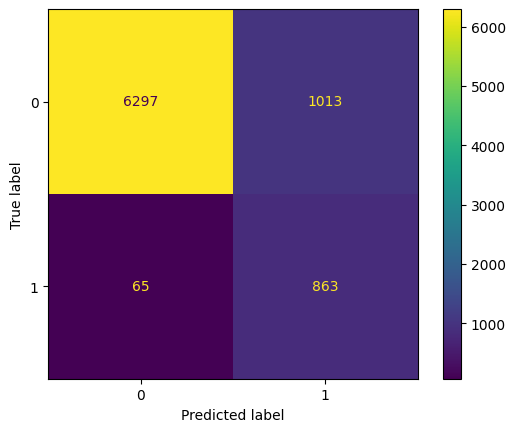

In [55]:
cm_lg_f2 = confusion_matrix(y_test, y_test_lg_f2_best)

ConfusionMatrixDisplay(confusion_matrix=cm_lg_f2).plot();

### 4.1.6. Business Metrics

In [56]:
business_perf_lg_f2 = business_metrics_func(y_test, y_test_lg_f2_best, 'lg f2')
business_perf_lg_f2

,Metric,Value
0,Model,lg f2
1,Revenue,20607
2,Cost,15652
3,ROI,0.32
4,Conversion Rate,0.46
5,Lost Opportunity,388
6,True Positive,863
7,False Positive,1013
8,True Negative,6297
9,False Negative,65


## 4.2. XGB Classifier F2

### 4.2.1. Declaring Tuning Pipeline

In [57]:
# param_xg = {
#     'model__n_estimators': [100, 200, 500],
#     'model__learning_rate': [0.01,0.05,0.1],
#     'model__booster': ['gbtree', 'gblinear'],
#     'model__gamma': [0, 0.5, 1],
#     'model__reg_alpha': [0, 0.5, 1],
#     'model__reg_lambda': [0.5, 1, 5],
#     'model__base_score': [0.1, 0.2, 0.3, 0.4, 0.5]
# }

param_xg = {
    'model__n_estimators': [400, 500, 600, 700],
    'model__learning_rate': [0.01,0.05,0.1],
    'model__booster': ['gbtree', 'gblinear'],
    'model__gamma': [0, 0.5, 1],
    'model__reg_alpha': [0, 0.5, 1],
    'model__reg_lambda': [0.5, 1, 5, 10],
    'model__base_score': [0.1, 0.2, 0.3, 0.4, 0.5]
}



In [58]:
xg_f2_cv = RandomizedSearchCV( estimator = pipe_xg, 
                                param_distributions=param_xg, 
                                n_iter=20, 
                                cv=5, 
                                # random_state=2042, 
                                scoring=f2_scorer)

### 4.1.2. Hyperparameter Tuning

In [59]:
xg_f2 = xg_f2_cv.fit(X_train, y_train)

In [60]:
best_xg_f2 = xg_f2.best_estimator_

best_xg_f2.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehot_encoding', ...), ('binary_encoding', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [61]:
y_train_xg_f2_best = best_xg_f2.predict(X_train)
y_test_xg_f2_best = best_xg_f2.predict(X_test)

### 4.1.3. Evaluation Metrics

In [62]:
# Evaluate the performance
f2_train_xg_f2 = fbeta_score(y_train, y_train_xg_f2_best, beta=1)
f2_test_xg_f2 = fbeta_score(y_test, y_test_xg_f2_best, beta=1)

print("Evaluation Metrics")
f2_xg_eval = {
    "Metric": [ "f2 Train",      "f2 Test", "difference"],
    "Value": [  f2_train_xg_f2,  f2_test_xg_f2, abs(f2_train_xg_f2-f2_test_xg_f2)]
}

# Create DataFrame
df_f2_xg_eval = pd.DataFrame(f2_xg_eval)
df_f2_xg_eval

Evaluation Metrics


,Metric,Value
0,f2 Train,0.655842
1,f2 Test,0.618893
2,difference,0.036950


### 4.1.4. Classification Report

In [63]:
print(classification_report(y_test, y_test_xg_f2_best))

              precision    recall  f1-score   support

           0       0.99      0.87      0.92      7310
           1       0.47      0.92      0.62       928

    accuracy                           0.87      8238
   macro avg       0.73      0.89      0.77      8238
weighted avg       0.93      0.87      0.89      8238



### 4.1.5. Confusion Matrix

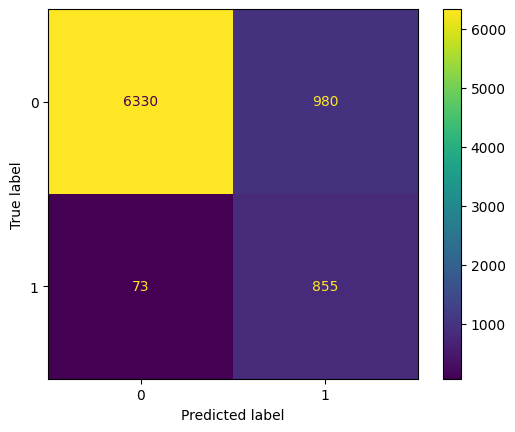

In [64]:
cm_xg_f2 = confusion_matrix(y_test, y_test_xg_f2_best)

ConfusionMatrixDisplay(confusion_matrix=cm_xg_f2).plot();

### 4.1.6. Business Metrics

In [65]:
business_perf_xg_f2 = business_metrics_func(y_test, y_test_xg_f2_best, 'XG f2')
business_perf_xg_f2

,Metric,Value
0,Model,XG f2
1,Revenue,20416
2,Cost,15532
3,ROI,0.31
4,Conversion Rate,0.47
5,Lost Opportunity,435
6,True Positive,855
7,False Positive,980
8,True Negative,6330
9,False Negative,73


# 5. Business & Model Metrics Performance Summary

In [66]:
business_summary_data = [
        ['Non Model', originaldata_costs, originaldata_income, (originaldata_income-originaldata_costs), originaldata_conv_rate, originaldata_roi],
        ['XGBoost Classifier Tuned', business_perf_xg_f2.iloc[2,1], business_perf_xg_f2.iloc[1,1], business_perf_xg_f2.iloc[1,1]-business_perf_xg_f2.iloc[2,1], business_perf_xg_f2.iloc[4,1], business_perf_xg_f2.iloc[3,1]],
        ['LigghtGBM Tuned', business_perf_lg_f2.iloc[2,1], business_perf_lg_f2.iloc[1,1], business_perf_lg_f2.iloc[1,1]-business_perf_lg_f2.iloc[2,1], business_perf_lg_f2.iloc[4,1], business_perf_lg_f2.iloc[3,1]],
        ]
business_summary = pd.DataFrame(business_summary_data, columns=['Type', 'Total Cost', 'Total Income', 'Net Profit', 'Conversion Rate', 'Net ROI'])
business_summary

,Type,Total Cost,Total Income,Net Profit,Conversion Rate,Net ROI
0,Non Model,737805,110798,-627007,0.11,-0.85
1,XGBoost Classifier Tuned,15532,20416,4884,0.47,0.31
2,LigghtGBM Tuned,15652,20607,4955,0.46,0.32


# 6. Feature Assessments

## 6.1. Feature Importance

In [67]:
column_names = best_xg_f2.named_steps['preprocessing'].get_feature_names_out()


In [68]:
column_names

array(['marital_married', 'marital_single', 'marital_unknown',
       'contact_telephone', 'default_unknown', 'default_yes',
       'housing_unknown', 'housing_yes', 'loan_unknown', 'loan_yes',
       'poutcome_nonexistent', 'poutcome_success', 'job_0', 'job_1',
       'job_2', 'job_3', 'age', 'campaign', 'pdays', 'previous',
       'cons.conf.idx', 'past_contacted', 'euribor3m', 'nr.employed',
       'cons.price.idx', 'education', 'day_of_week', 'emp.var.rate',
       'month', 'duration'], dtype=object)

In [69]:
fi_featimpo = best_xg_f2.named_steps['model'].feature_importances_

In [70]:
check_fi_df = pd.DataFrame({'feature': column_names, 'importance': fi_featimpo})
check_fi_df.sort_values(by='importance', ascending=False)

,feature,importance
23,nr.employed,0.511350
29,duration,0.106937
20,cons.conf.idx,0.070206
27,emp.var.rate,0.061627
22,euribor3m,0.042058
4,default_unknown,0.018889
24,cons.price.idx,0.018771
18,pdays,0.018447
11,poutcome_success,0.016464
3,contact_telephone,0.013259


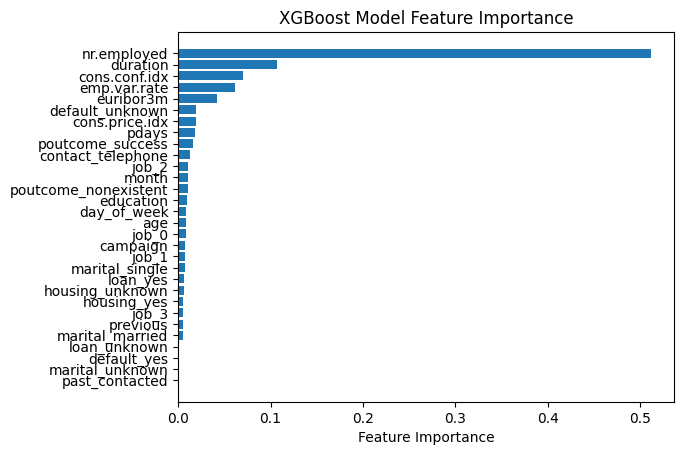

In [71]:
feature_importances = best_xg_f2.named_steps['model'].feature_importances_

feature_importances_df = pd.DataFrame({
        'Feature': column_names,
        'Importance': feature_importances
    })
sorted_fi_df = feature_importances_df.sort_values(by='Importance', ascending=False)

plt.barh(sorted_fi_df['Feature'], sorted_fi_df['Importance'])
plt.xlabel('Feature Importance')
plt.title('XGBoost Model Feature Importance')
plt.gca().invert_yaxis()
plt.show()

## 6.2. Shap

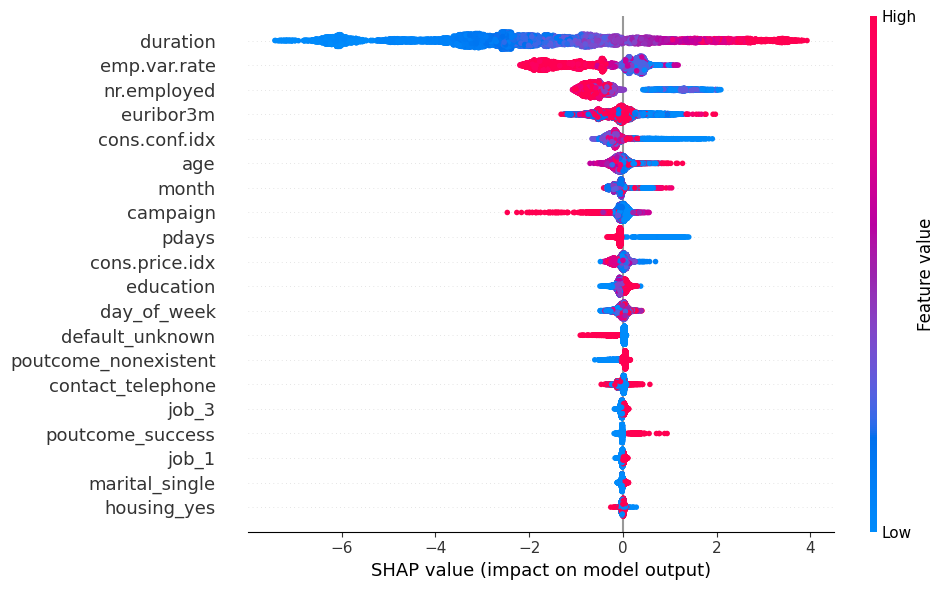

In [72]:
# Apply preprocessing to get the transformed feature names
X_train_tf = preprocessor.transform(X_train)
X_test_tf = preprocessor.transform(X_test)

# Feature name
unique_feature_names = best_xg_f2.named_steps['preprocessing'].get_feature_names_out()

# create a SHAP TreeExplainer
explainer = shap.TreeExplainer(best_xg_f2.named_steps['model'])

# calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_tf)

# visualize global feature importance
shap.summary_plot(shap_values, X_test_tf,
                  feature_names=unique_feature_names,
                  title="SHAP Summary Plot",
                  plot_size=(10, 6))

# 7. Counterfactual

## 7.1. Counterfactual Set Up

In [192]:
train_df = X_train.copy()
test_df = X_test.copy()

# Specify Numerical Columns
cont_features = list(train_df.select_dtypes('number').columns)

train_df['Deposit'] = y_train.reset_index(drop=True)

# Define the Data Interface
data_interface = dice_ml.Data(dataframe=train_df, continuous_features=cont_features, outcome_name='Deposit')

# Define the Model Interface
model_interface = dice_ml.Model(model=best_xg_f2, backend='sklearn')

# Initialize Dice
dice = Dice(data_interface, model_interface)

In [193]:
# Generate Counterfactuals
pd.set_option('display.max_columns', None)
cf = dice.generate_counterfactuals(test_df.reset_index(drop=True).loc[[98]], desired_class='opposite', total_CFs=5)

# Display
cf.visualize_as_dataframe(show_only_changes=True)

# Store Generated Counterfactual Instance
counterfact_sample1 = cf.cf_examples_list[0].final_cfs_df

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]


ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:euribor3m: object, nr.employed: object, cons.price.idx: object, education: object, day_of_week: object, emp.var.rate: object, month: object, duration: object

## 7.2 Generating Probabilities

### 7.2.1. Generating Counterfactual (1)

In [ ]:
# Get the probability for the positive class (Deposit) for the counterfactual
probability_sample_1 = ada_rs_best_pipe.predict_proba(cf_sample_1)[0, 1]
probability_sample_1

np.float64(0.5013928885483211)

In [ ]:
sample = int(X_test.sample(n=1).index[0])

# Generate Counterfactuals
pd.set_option('display.max_columns', None)
cf = dice.generate_counterfactuals(X_test.reset_index(drop=True).loc[[ sample ]], desired_class='opposite', total_CFs=3,
                                   features_to_vary='all')

# Display
cf.visualize_as_dataframe(show_only_changes=True)

# Store Generated Counterfactual Instance
cf_sample_2 = cf.cf_examples_list[0].final_cfs_df

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:01<00:00,  1.27s/it]

Query instance (original outcome : 0)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,past_contacted,Deposit
0,40,technician,married,6,no,yes,no,cellular,5,4,580,1,999,1,failure,-1.8,92.892998,-46.200001,1.266,5099.100098,1,0



Diverse Counterfactual set (new outcome: 1)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,past_contacted,Deposit
0,-,-,-,-,-,-,-,-,3,-,-,-,-,-,-,-,-,-35.9,-,-,-,1
1,-,-,-,-,yes,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,1
2,-,-,-,-,-,no,-,-,3,-,-,-,-,-,-,-,-,-,-,-,-,1


### 7.2.2. Generating Counterfactual (2)

In [ ]:
# Get the probability for the positive class (Deposit) for the counterfactual
probability_sample2 = ada_rs_best_pipe.predict_proba(cf_sample_2)[0, 1]
probability_sample2

np.float64(0.5041635734881935)

In [ ]:
sample = int(X_train.sample(n=1).index[0])

# Generate Counterfactuals
pd.set_option('display.max_columns', None)
cf = dice.generate_counterfactuals(X_test.reset_index(drop=True).loc[[ sample ]], desired_class='opposite', total_CFs=3,
                                   features_to_vary='all')

# Display
cf.visualize_as_dataframe(show_only_changes=True)

# Store Generated Counterfactual Instance
cf_sample_3 = cf.cf_examples_list[0].final_cfs_df

100%|██████████| 1/1 [00:05<00:00,  5.03s/it]

Query instance (original outcome : 0)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,past_contacted,Deposit
0,35,blue-collar,married,4,unknown,no,no,telephone,6,5,76,12,999,0,nonexistent,1.4,94.464996,-41.799999,4.959,5228.100098,0,0



Diverse Counterfactual set (new outcome: 1)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,past_contacted,Deposit
0,-,-,-,-,-,-,-,cellular,12,-,-,-,-,2,-,-,-,-,0.795,-,-,1
1,-,-,-,-,-,unknown,-,cellular,-,4,-,-,-,7,-,-,-,-,2.546,-,-,1
2,-,-,-,-,-,unknown,-,cellular,-,4,-,-,-,-,-,-,-,-,2.546,-,-,1


### 7.2.3. Generating Counterfactual (3)

In [ ]:
# Get the probability for the positive class (Deposit) for the counterfactual
probability_sample3 = ada_rs_best_pipe.predict_proba(cf_sample_3)[0, 1]
probability_sample3

np.float64(0.5170717718641128)

In [ ]:
sample = int(X_train.sample(n=1).index[0])

# Generate Counterfactuals
pd.set_option('display.max_columns', None)
cf = dice.generate_counterfactuals(X_test.reset_index(drop=True).loc[[ sample ]], desired_class='opposite', total_CFs=3,
                                   features_to_vary='all')
# Display
cf.visualize_as_dataframe(show_only_changes=True)

# Store Generated Counterfactual Instance
cf_sample_4 = cf.cf_examples_list[0].final_cfs_df

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:02<00:00,  2.64s/it]

Query instance (original outcome : 0)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,past_contacted,Deposit
0,30,admin.,single,7,no,no,no,cellular,7,1,171,4,999,0,nonexistent,1.4,93.917999,-42.700001,4.962,5228.100098,0,0



Diverse Counterfactual set (new outcome: 1)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,past_contacted,Deposit
0,-,-,-,-,-,-,yes,-,-,-,-,-,-,-,-,-,-,-,-,-,-,1
1,-,-,-,-,-,-,-,-,-,-,4706,-,-,-,-,-,-,-,-,-,-,1
2,-,-,-,-,-,-,-,-,-,-,3836,-,-,-,-,-,-,-,-,-,-,1


### 7.2.4. Generating Counterfactual (4)

In [ ]:
# Get the probability for the positive class (Deposit) for the counterfactual
probability_sample4 = ada_rs_best_pipe.predict_proba(cf_sample_4)[0, 1]
probability_sample4

np.float64(0.5007372955857531)

In [ ]:
sample = int(X_test.sample(n=1).index[0])

# Generate Counterfactuals
pd.set_option('display.max_columns', None)
cf = dice.generate_counterfactuals(X_test.reset_index(drop=True).loc[[ sample ]], desired_class='opposite', total_CFs=3,
                                   features_to_vary='all')

# Display
cf.visualize_as_dataframe(show_only_changes=True)

# Store Generated Counterfactual Instance
counterfact = cf.cf_examples_list[0].final_cfs_df

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:02<00:00,  2.94s/it]

Query instance (original outcome : 0)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,past_contacted,Deposit
0,26,blue-collar,single,5,no,no,no,telephone,5,5,213,4,999,0,nonexistent,1.1,93.994003,-36.400002,4.855,5191.0,0,0



Diverse Counterfactual set (new outcome: 1)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,past_contacted,Deposit
0,-,-,-,-,-,-,-,cellular,-,-,-,-,-,-,-,-,-,-,-,-,-,1
1,-,-,-,-,-,-,-,-,3,-,-,-,-,-,-,-,-,-,-,-,-,1
2,-,-,-,-,-,-,-,cellular,-,-,-,-,-,-,-,-,-,-,-,-,-,1
